# VizWiz-VQA Code Dissection

## Installing required libraries

In [1]:
!pip install ftfy
!pip install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.0 MB/s eta 0:00:0000:0100:01


## Importing required libraries

In [2]:
# Importing OS for system operations, numpy and pandas for data manipulation
import os
import numpy as np 
import pandas as pd

# Importing tqdm to track computation progress
from tqdm.notebook import tqdm
# Importing tabulate for printing formatted results table
from tabulate import tabulate

# For data visualization, we will use matplotlib
import matplotlib.pyplot as plt

# For data preprocessing, we will use Counter, train_test_split, Levenshtein distance, Python Image Library and OneHotEncoder
from collections import Counter
import Levenshtein as lev
from PIL import Image
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# For saving and loading the preprocessed data, we will use pickle
import pickle

# For Building the model, we will use PyTorch and its functions
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# For evaluation, we will need sklearn.metrics.average_precision_score
from sklearn.metrics import average_precision_score

# Importing json for results formatting which will be uploaded for evaluation
import json

## Configuring the Notebook

In [3]:
# Configuring the paths for the dataset
INPUT_PATH = '/kaggle/input/vizwiz-2023-edition'
ANNOTATIONS_PATH = INPUT_PATH + '/Annotations'
TRAIN_PATH = INPUT_PATH + '/train/train'
VALIDATION_PATH = INPUT_PATH + '/val/val'
ANNOTATIONS_TRAIN_PATH = ANNOTATIONS_PATH + '/train.json'
ANNOTATIONS_VAL_PATH = ANNOTATIONS_PATH + '/val.json'
OUTPUT_PATH = '/kaggle/working/'

# Using accelerated computing if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", DEVICE)

Device:  cpu


## Basic structure of the data

In [4]:
def read_dataframe(path):
    """
    Reads the JSON file and returns a dataframe with the required columns (image, question, answers, answer_type, answerable)

    Parameters:
        path (str): Path to the JSON file

    Returns:
        df (pandas.DataFrame): Dataframe with the required columns
    """
    df = pd.read_json(path)
    df = df[['image', 'question', 'answers', 'answer_type', 'answerable']]
    return df

In [5]:
train_df = read_dataframe(ANNOTATIONS_TRAIN_PATH)
val_df = read_dataframe(ANNOTATIONS_VAL_PATH)

In [6]:
# num_df = train_df[train_df['answer_type'] == 'number'][:3]
# u_df = train_df[train_df['answer_type'] == 'unanswerable'][:1]
# train_df = pd.concat([train_df[:10], num_df, u_df], ignore_index=True)

# num_val_df = val_df[val_df['answer_type'] == 'number'][:1]
# yn_val_df = val_df[val_df['answer_type'] == 'yes/no'][:1]
# val_df = pd.concat([val_df[:5], num_val_df, yn_val_df], ignore_index=True)

In [7]:
train_df.head()

,image,question,answers,answer_type,answerable
0,VizWiz_train_00000000.jpg,What's the name of this product?,"[{'answer_confidence': 'yes', 'answer': 'basil...",other,1
1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,"[{'answer_confidence': 'yes', 'answer': 'soda'...",other,1
2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? ...,"[{'answer_confidence': 'yes', 'answer': 'these...",other,1
3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,"[{'answer_confidence': 'yes', 'answer': 't36m'...",other,1
4,VizWiz_train_00000004.jpg,What is this item?,"[{'answer_confidence': 'yes', 'answer': 'solar...",other,1


In [8]:
train_df.iloc[0].answers

[{'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil'},
 {'answer_confidence': 'yes', 'answer': 'basil'},
 {'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil leaves'},
 {'answer_confidence': 'yes', 'answer': 'basil'}]

In [9]:
for answer_map in train_df.iloc[0].answers:
    print(answer_map['answer'])

basil leaves
basil leaves
basil
basil
basil leaves
basil leaves
basil leaves
basil leaves
basil leaves
basil


basil leaves
basil leaves
basil
basil
basil leaves
basil leaves
basil leaves
basil leaves
basil leaves
basil


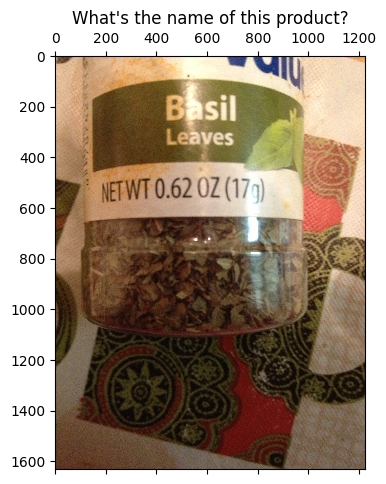

In [10]:
idx = 0
example_image_path = TRAIN_PATH + "/" + train_df.iloc[idx].image
example_question = train_df.iloc[idx].question
image = Image.open(example_image_path).convert("RGB")
plt.matshow(image)
plt.title(example_question)
for answer_map in train_df.iloc[idx].answers:
    print(answer_map['answer'])

## Image and Text Encoder output analysis

In [11]:
from transformers import AutoTokenizer, AutoFeatureExtractor, AutoModel

text_processor = AutoTokenizer.from_pretrained("bert-base-uncased")
text_encoder = AutoModel.from_pretrained("bert-base-uncased")
for p in text_encoder.parameters():
    p.requires_grad = False

image_processor = AutoFeatureExtractor.from_pretrained("google/vit-base-patch32-224-in21k")
image_encoder = AutoModel.from_pretrained("google/vit-base-patch32-224-in21k")
for p in image_encoder.parameters():
    p.requires_grad = False

image_encoder.to(DEVICE)
text_encoder.to(DEVICE)

print(f"Encoders successfully loaded with {DEVICE}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

2025-07-24 15:20:57.592564: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753370457.827084      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753370457.899596      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


...

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


model.safetensors:   0%|          | 0.00/352M [00:00<?, ?B/s]

Encoders successfully loaded with cpu


### Question encoder analysis (bert-base-uncased)

In [12]:
question = train_df.iloc[0].question
question

"What's the name of this product?"

In [13]:
text_input = text_processor(question, padding='max_length', truncation=True, max_length=16, return_tensors="pt")
# text_inputs = {k:v.to(device) for k,v in text_inputs.items()}
for k, v in text_input.items():
    print(k, v)

test_input = text_processor("the", padding='max_length', truncation=True, max_length=16, return_tensors="pt")
for k, v in test_input.items():
    print(k, v)

input_ids tensor([[ 101, 2054, 1005, 1055, 1996, 2171, 1997, 2023, 4031, 1029,  102,    0,
            0,    0,    0,    0]])
token_type_ids tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
attention_mask tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]])
input_ids tensor([[ 101, 1996,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]])
token_type_ids tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
attention_mask tensor([[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


In [14]:
text_outputs = text_encoder(**text_input)
text_outputs.pooler_output.shape, text_outputs.last_hidden_state.shape

(torch.Size([1, 768]), torch.Size([1, 16, 768]))

In [15]:
text_embedding = text_outputs.last_hidden_state
text_embedding = text_embedding.detach()
text_embedding = text_embedding.squeeze(0)
text_embedding.shape

torch.Size([16, 768])

### Image encoder analysis (google/vit-base-patch32-224-in21k)

In [16]:
image_path = TRAIN_PATH + "/" + train_df.iloc[0].image
image = Image.open(image_path).convert("RGB")
image_inputs = image_processor(image, return_tensors="pt")
# image_inputs = {k:v.to(device) for k,v in image_inputs.items()}

# The image processor processes the image to a fixed size of [B, C, W, H] where W and H = 224
image_inputs['pixel_values'].shape

torch.Size([1, 3, 224, 224])

In [17]:
image_outputs = image_encoder(**image_inputs)
image_embedding = image_outputs.last_hidden_state
image_embedding = image_embedding.detach()
image_embedding = image_embedding.squeeze(0)
# Patch size = 224 / 32 = 7
# Seq length 7X7 + 1 = 50
image_embedding.shape

torch.Size([50, 768])

## Answer vocabulary creation analysis

### Training dataset

In [11]:
# Total counter for all answers before filtering, used in Tie Breaking when building the answer vocabulary
global_answer_vocab = Counter()
for row in train_df['answers']:
    for answer_map in row:
        global_answer_vocab.update([answer_map['answer']])

In [12]:
len(global_answer_vocab)

41226

In [13]:
# Building answer vocab follow this policy:
# for each question we have 10 answers, we choose the most frequent answer as the answer for this question
# if there is a tie, we choose the most common one in the whole dataset
# if there is a tie, the pairwise Levenshtein distance is used to find the answer that is most representative to all others.

# Copying the original dataframe which will be manipulated
copied_dataframe = train_df.copy()
copied_dataframe.drop(columns=['answers'], inplace=True)

# Adding extra column named 'answer'
copied_dataframe['answer'] = None

freq_counter = Counter()
freq_counter2 = Counter()
cnt = 0

for index, row in train_df.iterrows():
    intermediate_counter = Counter()
    for answer_map in row['answers']:
        answer = answer_map['answer']
        intermediate_counter.update([answer])
            
    # let's see the top elements in the intermediate_counter to check if there is a tie
    top_freq = max(intermediate_counter.values())
    top_elements = [(k, v) for k, v in intermediate_counter.items() if v == top_freq]

    freq_counter.update([len(top_elements)])

    if len(top_elements) == 1:
        copied_dataframe.at[index, 'answer'] = top_elements[0][0]
        continue
                
    # Else let's see who is the most common answer in the whole dataset
    top_elements_in_dataset = []
    top_freq = -1
    for k, v in top_elements:
        if global_answer_vocab[k] > top_freq:
            top_freq = global_answer_vocab[k]
            top_elements_in_dataset.clear()
            top_elements_in_dataset.append(k)
        elif global_answer_vocab[k] == top_freq:
            top_elements_in_dataset.append(k)

    freq_counter2.update([len(top_elements_in_dataset)])
    
    if len(top_elements_in_dataset) == 1:
        copied_dataframe.at[index, 'answer'] = top_elements_in_dataset[0]
        continue
                
    # Else let's get the minimum levenshtein distance between the answers in top_elements_in_dataset
    cnt += 1
    current_min = np.inf
    current_answer = None
    for answer in top_elements_in_dataset:
        total_distance = 0
        for answer2 in top_elements_in_dataset:
            if answer != answer2:
                lev_distance = lev.distance(answer, answer2)
                total_distance += lev_distance
        if total_distance < current_min:
            current_min = total_distance
            current_answer = answer
    copied_dataframe.at[index, 'answer'] = current_answer

print("Length frequency of candidate answer sets in first stage filtering:")
for k, v in freq_counter.items():
    print(k, v)

print("Length frequency of candidate answer sets in second stage filtering:")
for k, v in freq_counter2.items():
    print(k, v)

print("Number of candidate answer sets in third stage filtering:")
print(cnt)

Length frequency of candidate answer sets in first stage filtering:
1 18270
2 1525
10 412
3 276
4 39
5 1
Length frequency of candidate answer sets in second stage filtering:
1 2055
2 151
10 27
4 2
3 18
Number of candidate answer sets in third stage filtering:
198


In [14]:
len(copied_dataframe['answer'].unique())

4833

### Validation dataset

In [15]:
# Total counter for all answers before filtering, used in Tie Breaking when building the answer vocabulary for validation dataset
global_answer_vocab_val = Counter()
for row in val_df['answers']:
    for answer_map in row:
        global_answer_vocab_val.update([answer_map['answer']])

In [16]:
len(global_answer_vocab_val)

10903

In [17]:
# Copying the original dataframe which will be manipulated
copied_dataframe2 = val_df.copy()
copied_dataframe2.drop(columns=['answers'], inplace=True)

# Adding extra column named 'answer'
copied_dataframe2['answer'] = None

freq_counter = Counter()
freq_counter2 = Counter()
cnt = 0

for index, row in val_df.iterrows():
    intermediate_counter = Counter()
    for answer_map in row['answers']:
        answer = answer_map['answer']
        intermediate_counter.update([answer])
            
    # let's see the top elements in the intermediate_counter to check if there is a tie
    top_freq = max(intermediate_counter.values())
    top_elements = [(k, v) for k, v in intermediate_counter.items() if v == top_freq]

    freq_counter.update([len(top_elements)])

    if len(top_elements) == 1:
        copied_dataframe2.at[index, 'answer'] = top_elements[0][0]
        continue
                
    # Else let's see who is the most common answer in the whole dataset
    top_elements_in_dataset = []
    top_freq = -1
    for k, v in top_elements:
        if global_answer_vocab_val[k] > top_freq:
            top_freq = global_answer_vocab_val[k]
            top_elements_in_dataset.clear()
            top_elements_in_dataset.append(k)
        elif global_answer_vocab_val[k] == top_freq:
            top_elements_in_dataset.append(k)

    freq_counter2.update([len(top_elements_in_dataset)])
    
    if len(top_elements_in_dataset) == 1:
        copied_dataframe2.at[index, 'answer'] = top_elements_in_dataset[0]
        continue
                
    # Else let's get the minimum levenshtein distance between the answers in top_elements_in_dataset
    cnt += 1
    current_min = np.inf
    current_answer = None
    for answer in top_elements_in_dataset:
        total_distance = 0
        for answer2 in top_elements_in_dataset:
            if answer != answer2:
                lev_distance = lev.distance(answer, answer2)
                total_distance += lev_distance
        if total_distance < current_min:
            current_min = total_distance
            current_answer = answer
    copied_dataframe2.at[index, 'answer'] = current_answer

print("Length frequency of candidate answer sets in first stage filtering:")
for k, v in freq_counter.items():
    print(k, v)

print("Length frequency of candidate answer sets in second stage filtering:")
for k, v in freq_counter2.items():
    print(k, v)

print("Number of candidate answer sets in third stage filtering:")
print(cnt)

Length frequency of candidate answer sets in first stage filtering:
1 3866
2 307
10 85
4 10
3 51
Length frequency of candidate answer sets in second stage filtering:
1 382
10 15
2 51
3 5
Number of candidate answer sets in third stage filtering:
71


In [18]:
len(copied_dataframe2['answer'].unique())

1333

In [19]:
training_vocab = copied_dataframe['answer'].unique()
validation_vocab = copied_dataframe2['answer'].unique()

In [22]:
cnt = 0
cnt2 = 0
for answer in validation_vocab:
    if answer not in training_vocab:
        cnt += 1
        cnt2 += global_answer_vocab_val[answer]
print(f"{cnt} answers in validation answer vocab are not present in training answer vocab")
print(cnt2)

728 answers in validation answer vocab are not present in training answer vocab
3947


In [21]:
val_useful_samples = val_df.shape[0] - cnt2
print(val_useful_samples)

372


### Joint Vocabulary

In [33]:
joint_df = pd.concat([train_df, val_df], ignore_index=True)

In [48]:
# Total counter for all answers before filtering, used in Tie Breaking when building the answer vocabulary for joint dataset
global_answer_vocab_joint = Counter()
for row in joint_df['answers']:
    for answer_map in row:
        global_answer_vocab_joint.update([answer_map['answer']])

In [49]:
len(global_answer_vocab_joint)

48727

In [51]:
# Copying the original dataframe which will be manipulated
copied_dataframe3 = joint_df.copy()
copied_dataframe3.drop(columns=['answers'], inplace=True)

# Adding extra column named 'answer'
copied_dataframe3['answer'] = None

freq_counter = Counter()
freq_counter2 = Counter()
cnt = 0

for index, row in joint_df.iterrows():
    intermediate_counter = Counter()
    for answer_map in row['answers']:
        answer = answer_map['answer']
        intermediate_counter.update([answer])
            
    # let's see the top elements in the intermediate_counter to check if there is a tie
    top_freq = max(intermediate_counter.values())
    top_elements = [(k, v) for k, v in intermediate_counter.items() if v == top_freq]

    freq_counter.update([len(top_elements)])

    if len(top_elements) == 1:
        copied_dataframe3.at[index, 'answer'] = top_elements[0][0]
        continue
                
    # Else let's see who is the most common answer in the whole dataset
    top_elements_in_dataset = []
    top_freq = -1
    for k, v in top_elements:
        if global_answer_vocab_joint[k] > top_freq:
            top_freq = global_answer_vocab_joint[k]
            top_elements_in_dataset.clear()
            top_elements_in_dataset.append(k)
        elif global_answer_vocab_joint[k] == top_freq:
            top_elements_in_dataset.append(k)

    freq_counter2.update([len(top_elements_in_dataset)])
    
    if len(top_elements_in_dataset) == 1:
        copied_dataframe3.at[index, 'answer'] = top_elements_in_dataset[0]
        continue
                
    # Else let's get the minimum levenshtein distance between the answers in top_elements_in_dataset
    cnt += 1
    current_min = np.inf
    current_answer = None
    for answer in top_elements_in_dataset:
        total_distance = 0
        for answer2 in top_elements_in_dataset:
            if answer != answer2:
                lev_distance = lev.distance(answer, answer2)
                total_distance += lev_distance
        if total_distance < current_min:
            current_min = total_distance
            current_answer = answer
    copied_dataframe3.at[index, 'answer'] = current_answer

print("Length frequency of candidate answer sets in first stage filtering:")
for k, v in freq_counter.items():
    print(k, v)

print("Length frequency of candidate answer sets in second stage filtering:")
for k, v in freq_counter2.items():
    print(k, v)

print("Number of candidate answer sets in third stage filtering:")
print(cnt)

Length frequency of candidate answer sets in first stage filtering:
1 22136
2 1832
10 497
3 327
4 49
5 1
Length frequency of candidate answer sets in second stage filtering:
1 2505
2 148
10 32
4 2
3 19
Number of candidate answer sets in third stage filtering:
201


In [52]:
len(copied_dataframe3['answer'].unique())

5545